In [7]:
%load_ext autoreload
%autoreload 2
%load_ext kedro.extras.extensions.ipython
%reload_kedro /home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models
%matplotlib inline
import pandas as pd
from vessel_manoeuvring_models.models.vmm import ModelSimulator
import matplotlib.pyplot as plt
from vessel_manoeuvring_models.visualization.plot import track_plots, plot
import kedro

import matplotlib

matplotlib.rcParams["figure.figsize"] = (15, 4)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The kedro.extras.extensions.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.extras.extensions.ipython
2026-03-31 16:24:56,883 - kedro.framework.session.store - INFO - `read()` not implemented for `SQLiteStore`. Assuming empty store.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/kedro/framework/context/context.py:488: UserWarning: Credentials not found in your Kedro project config.
No files found in ['/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/base', '/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/local'] matching the glob pattern(s): ['credentials*', 'credentials*/**', '**/credentials*']
  warn(f"Credentials not found in your Kedro project config.\n{str(exc)}")


2026-03-31 16:24:58,638 - root - INFO - ** Kedro project wPCC_pipeline
2026-03-31 16:24:58,642 - root - INFO - Defined global variable `context`, `session`, `catalog` and `pipelines`
2026-03-31 16:24:58,664 - root - INFO - Registered line magic `run_viz`


In [4]:
id = "22773"
df = catalog.load(f"wpcc.{id}.data")
df_smooth = catalog.load(f"wpcc.initial.{id}.data_ek_smooth")
model = catalog.load("wpcc.initial.vmm_martins_simple.joined.model")

2026-03-31 16:21:40,793 - kedro.io.data_catalog - INFO - Loading data from `wpcc.22773.data` (CSVDataSet)...
2026-03-31 16:21:40,924 - kedro.io.data_catalog - INFO - Loading data from `wpcc.initial.22773.data_ek_smooth` (CSVDataSet)...
2026-03-31 16:21:41,028 - kedro.io.data_catalog - INFO - Loading data from `wpcc.initial.vmm_martins_simple.joined.model` (PickleDataSet)...


In [5]:
result = model.simulate(df_=df)
result2 = model.simulate(df_=df_smooth)


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_

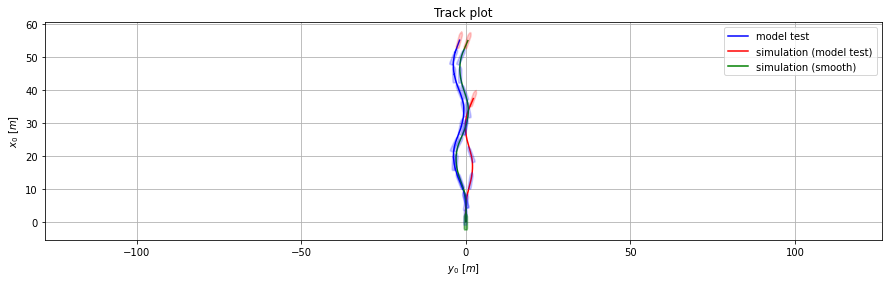

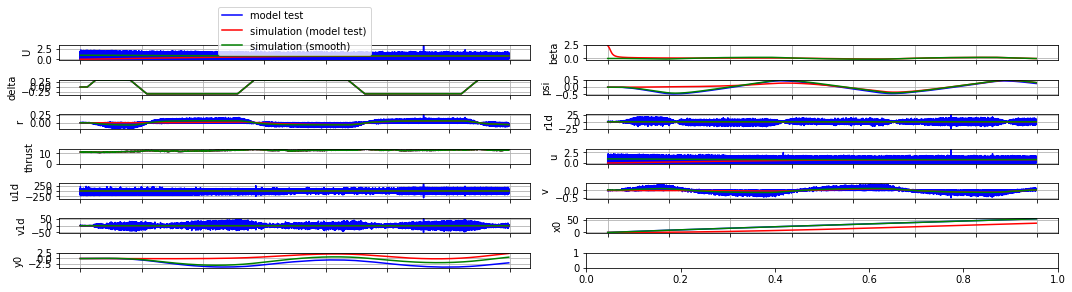

In [6]:
dataframes = {
    "model test": df,
    "simulation (model test)": result.result,
    "simulation (smooth)": result2.result,
}

fig, ax = plt.subplots()
track_plots(
    dataframes=dataframes,
    lpp=model.ship_parameters["L"],
    beam=model.ship_parameters["B"],
    ax=ax,
)
plot(dataframes, keys=result.result.columns);
